<a href="https://colab.research.google.com/github/abudofa2017-lgtm/Pharmacovigilance-data-practice-/blob/main/Project_Evaluation_Group_2_Assignment_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# **Project Group 2**

**Peace Nkire - SCA/APC3/DS/063**

**God'slove Ayotade - SCA/APC3/DS/066**

**Abasiama Udofa - SCA/APC3/DS/064**

In [ ]:
# importing libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# To paste the full shareable link here

share_link = 'https://drive.google.com/file/d/1t428fuaIreiyF4EsKTWDfyhPAhoT5Bpr/view?usp=drivesdk'

# To automatically extract the ID and create the direct download URL

file_id = share_link.split('/')[-2]
direct_url = f'https://drive.google.com/uc?export=download&id={file_id}'

# Reading into pandas

toyota_df = pd.read_csv(direct_url)
toyota_df

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,GT86,2016,16000,Manual,24089,Petrol,265,36.2,2.0
1,GT86,2017,15995,Manual,18615,Petrol,145,36.2,2.0
2,GT86,2015,13998,Manual,27469,Petrol,265,36.2,2.0
3,GT86,2017,18998,Manual,14736,Petrol,150,36.2,2.0
4,GT86,2017,17498,Manual,36284,Petrol,145,36.2,2.0
...,...,...,...,...,...,...,...,...,...
6733,IQ,2011,5500,Automatic,30000,Petrol,20,58.9,1.0
6734,Urban Cruiser,2011,4985,Manual,36154,Petrol,125,50.4,1.3
6735,Urban Cruiser,2012,4995,Manual,46000,Diesel,125,57.6,1.4
6736,Urban Cruiser,2011,3995,Manual,60700,Petrol,125,50.4,1.3


In [ ]:
# checking the dataset information

toyota_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6738 entries, 0 to 6737
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         6738 non-null   object 
 1   year          6738 non-null   int64  
 2   price         6738 non-null   int64  
 3   transmission  6738 non-null   object 
 4   mileage       6738 non-null   int64  
 5   fuelType      6738 non-null   object 
 6   tax           6738 non-null   int64  
 7   mpg           6738 non-null   float64
 8   engineSize    6738 non-null   float64
dtypes: float64(2), int64(4), object(3)
memory usage: 473.9+ KB


An inspection on the data was carried out using the .info() method and some inconsistencies were found in the data formats. This launched us into the cleaning of the dataset

The number of rows were also discovered as 6,738, while the number of columns were 9.

# Data Cleaning and Validation

In [ ]:
#we observed object data types instead of strings in the dataset info
#selecting all the columns with object data type and converting them to strings.
object_to_string = toyota_df.select_dtypes(include='object').columns
toyota_df[object_to_string] = toyota_df[object_to_string].astype('string')

# remove extra spaces from the strings
toyota_df[object_to_string] = toyota_df[object_to_string].apply(lambda x: x.str.strip().str.replace(r'\s+', ' ', regex=True))

We converted all the object data types to strings and removed all the empty spaces in order to avoid an incorrect analysis report.

In [ ]:
#To check for duplicate rows
duplicate_rows = toyota_df.duplicated().sum()
print("Number of duplicate rows:", duplicate_rows)

Number of duplicate rows: 39


In [ ]:
#To see duplicates
duplicates = toyota_df[toyota_df.duplicated(keep=False)]
#To sort them for easy viewing
duplicates.sort_values(by=list(toyota_df.columns))

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
3229,Auris,2013,6622,Manual,41959,Petrol,145,47.9,1.6
3230,Auris,2013,6622,Manual,41959,Petrol,145,47.9,1.6
3175,Auris,2016,8992,Manual,40323,Diesel,20,67.3,1.6
3177,Auris,2016,8992,Manual,40323,Diesel,20,67.3,1.6
2944,Auris,2016,9985,Manual,27600,Petrol,30,58.9,1.2
...,...,...,...,...,...,...,...,...,...
1964,Yaris,2019,12495,Automatic,6000,Petrol,145,47.9,1.5
2160,Yaris,2019,14495,Manual,100,Petrol,145,47.9,1.5
2161,Yaris,2019,14495,Manual,100,Petrol,145,47.9,1.5
1586,Yaris,2020,14769,Manual,25,Petrol,150,47.9,1.5


In [ ]:
#To remove the duplicate rows

toyota_df.drop_duplicates(inplace=True)
drop_duplicates = toyota_df.duplicated().sum()
print("Number of duplicate rows:", drop_duplicates)

Number of duplicate rows: 0


We identified 39 duplicate rows across all variables and we removed them because after viewing the duplicates, we discovered that they are 100% identical across all columns.

Removing duplicates without proper validation could bias the analysis by underrepresenting frequently sold car configurations.

So the remaining dataset ensures each observation represents a unique car sale.

In [ ]:
#To check for null/missing values
toyota_df.isnull().sum()

,0
model,0
year,0
price,0
transmission,0
mileage,0
fuelType,0
tax,0
mpg,0
engineSize,0


We checked for missing/ null values and discovered that there were no missing or null values.

In [ ]:
#To check for unique values in the categorical column
#To check for transmission
toyota_df['transmission'].unique()

<StringArray>
['Manual', 'Automatic', 'Semi-Auto', 'Other']
Length: 4, dtype: string

In [ ]:
#To check for fuelType
toyota_df['fuelType'].unique()


<StringArray>
['Petrol', 'Other', 'Hybrid', 'Diesel']
Length: 4, dtype: string

We inspected the categorical columns: "transmission" and "fuelType", checking for inconsistencies in the values and there were none, so no action was required.

In [ ]:
#To check if the year falls into the range specified in the document
toyota_df['year'].min()

1998

In [ ]:
toyota_df['year'].max()


2020

Both the minimum and the maximum years fall into range as specified in the car information file. So the "year" column has been validated.

In [ ]:
#To check if there is any value less than zero for the mileage
toyota_df['mileage'].min()

2

In [ ]:
#To check if there is any value less than zero for the price
toyota_df['price'].min()

850

Validation was carried out by checking for outliers and unrealistic values for the "mileage" and "price" columns and there were none.

In [ ]:
toyota_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6699 entries, 0 to 6737
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         6699 non-null   string 
 1   year          6699 non-null   int64  
 2   price         6699 non-null   int64  
 3   transmission  6699 non-null   string 
 4   mileage       6699 non-null   int64  
 5   fuelType      6699 non-null   string 
 6   tax           6699 non-null   int64  
 7   mpg           6699 non-null   float64
 8   engineSize    6699 non-null   float64
dtypes: float64(2), int64(4), string(3)
memory usage: 523.4 KB



Before the cleaning and validation of the dataset, the number of rows were 6,738.
After the cleaning and validation of the dataset, the rows left were 6,699.
39 duplicate rows were removed.
There were no empty values/cells. All the columns are within the expected ranges. Categorical columns have been standardised.
The data has now been properly cleaned and validated and is ready for exploratory analysis.
The final dataset is 6,699 rows and 9 columns.

# Exploratory Analysis

Using data visualization to show single variables and to demonstrate the characteristics of the data

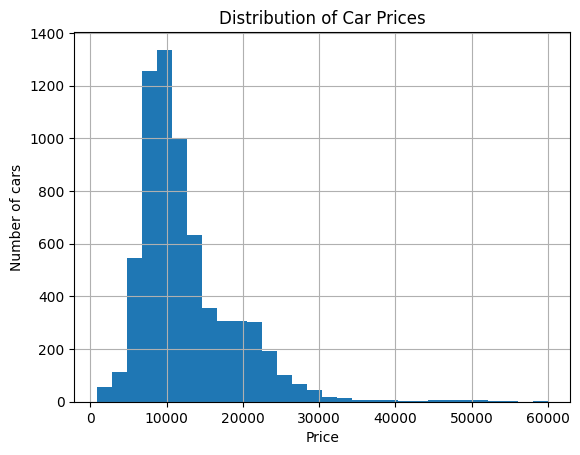

In [ ]:
# A histogram showing how many cars fall into each price range using the "price" variable
toyota_df["price"].hist(bins=30)
plt.title("Distribution of Car Prices")
plt.xlabel("Price")
plt.ylabel("Number of cars")
plt.show()

The histogram chart shows the insight about car prices, that most cars fall within the mid-price range of £5,000 to £20,000. A few premium cars exceed £30,000

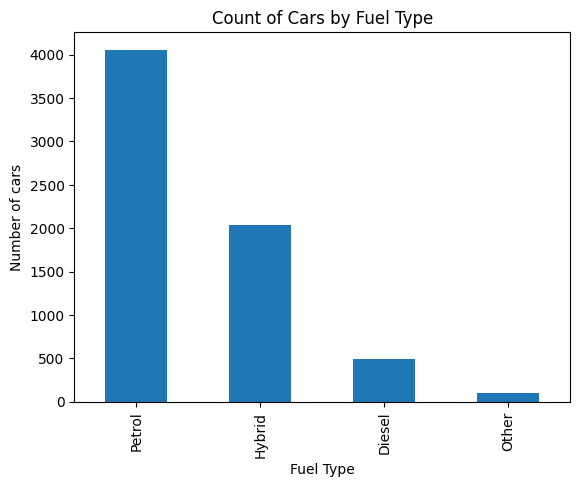

In [ ]:
# A bar chart showing the count of cars using the "fuelType" variable
toyota_df["fuelType"].value_counts().plot(kind='bar')
plt.title('Count of Cars by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Number of cars')
plt.show()

The insight gotten from the above bar chart is that petrol cars dominated the car market. Hybrid has lower count in the car market.

MULTIPLE VARIABLE ANALYSIS

Comparing Hybrid cars versus Others

In [ ]:

# grouping by fuel type and getting the average
average = toyota_df.groupby('fuelType')[['price', 'mileage', 'tax', 'mpg']].mean()

# rounding up to 2 decimal places
round(average, 2)

,price,mileage,tax,mpg
fuelType,,,,
Diesel,15740.16,41661.14,149.38,52.00
Hybrid,17187.81,24415.28,60.20,75.30
Other,14121.16,17159.90,100.52,71.18
Petrol,9754.59,19976.46,104.96,58.08


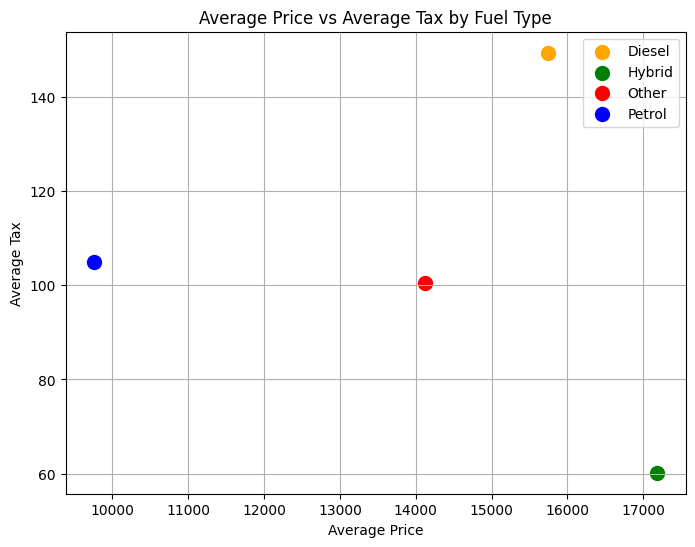

In [ ]:

#Creating a scatterplot
# Using the average table
average = toyota_df.groupby('fuelType')[['price', 'tax']].mean().round(2)

# Defining colours for each fuel type
colors = {'Petrol': 'blue', 'Diesel': 'orange', 'Hybrid': 'green', 'Other': 'red'}

plt.figure(figsize=(8,6))

# Plotting each fuel type separately so a legend is created
for fuelType in average.index:
    plt.scatter(average.loc[fuelType, 'price'], average.loc[fuelType, 'tax'],
                color=colors[fuelType], label=fuelType, s=100)

plt.title('Average Price vs Average Tax by Fuel Type')
plt.xlabel('Average Price')
plt.ylabel('Average Tax')
plt.legend()  # This adds the colour key at the top right
plt.grid(True)
plt.show()

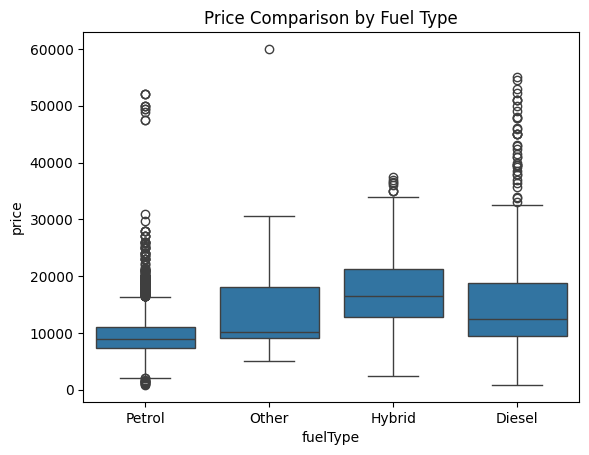

In [ ]:
sns.boxplot(x='fuelType', y='price', data=toyota_df)
plt.title("Price Comparison by Fuel Type")
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

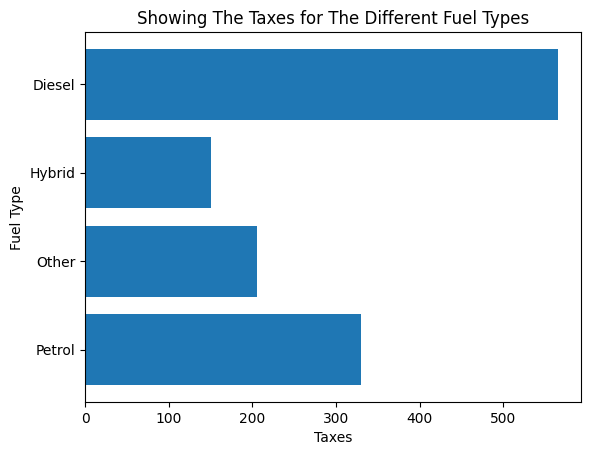

In [ ]:
# Plotting a horizontal bar chat to show the taxes on each fuel type

plt.barh(toyota_df["fuelType"], toyota_df["tax"])
plt.xlabel("Taxes")
plt.ylabel("Fuel Type")
plt.title("Showing The Taxes for The Different Fuel Types")
plt.show

A scatterplot, boxplot and a horizontal bar chart were used to get insights on multiple variables while comparing the hybrid fuel type with other fuel types and the insights gotten are:

1. Hybrid cars are generally more expensive since they have the highest average price.
2. Hybrid cars pay lowest tax compared to the petrol and diesel cars.

# A METRIC FOR THE BUSINESS TO MONITOR

In [ ]:
#Hybrid market share
#Dividing the total number of Hybrid rows by the total number of rows in the data.
# Multiplying the result of the division by 100 to get the percentage of Hybrid cars.
hybrid_count = toyota_df[toyota_df['fuelType'] == 'Hybrid'].shape[0]
total_count = toyota_df.shape[0]
hybrid_share = (hybrid_count / total_count) * 100

# rounding up the percentage to 2 decimal places.
print("The percentage of Hybrid cars to other cars in the sales share is", round(hybrid_share, 2),"%")

The percentage of Hybrid cars to other cars in the sales share is 30.45 %


The metric value for hybrid sales share, 30.45%, shows the percentage of Hybrid cars in the sales data.
This value helps to measure the adoption of ecofriendly vehicles (electric and hybrid cars), it also helps track progress towards the 2030 goal. The metric value makes sales easy to monitor monthly.

In [ ]:
#Hybrid price over petrol
#To show the comparison of hybrid car price over petrol car price
#Getting average car prices
avg_price = toyota_df.groupby('fuelType')['price'].mean()
avg_price_hybrid = avg_price['Hybrid']
avg_price_petrol = avg_price['Petrol']

#Subtracting the average price of petrol cars from that of hybrid cars
extra_cost = avg_price_hybrid - avg_price_petrol

#Finding the percentage higher value of hybrid cars over petrol cars
premium_pct = (extra_cost / avg_price_petrol) * 100

#Print the results
print("The average price of Hybrid cars is", round(avg_price_hybrid, 2), "and the average price of Petrol cars is", round(avg_price_petrol, 2))
print("The extra cost for Hybrid cars over petrol cars is", round(extra_cost, 2))
print("This means that the average price of a hybrid car is", round(premium_pct, 2), "% higher than the average price of a Petrol car")


The average price of Hybrid cars is 17187.81 and the average price of Petrol cars is 9754.59
The extra cost for Hybrid cars over petrol cars is 7433.22
This means that the average price of a hybrid car is 76.2 % higher than the average price of a Petrol car


It was observed that the Hybrid cars cost 76% more than petrol cars, this was gotten from the 6-months sales dataset.


In [ ]:
#Predictive Analysis
#The Total Cost of Ownership over 5 years (with assumptions) comparing hybrid cars to petrol cars
#Assumption values
annual_mileage = 15000 #miles per year
fuel_price_per_gallon = 7.2 #£ per gallon
years = 5

#Using the existing dataset to get the average mpg and the average tax
avg_mpg = toyota_df.groupby('fuelType')['mpg'].mean()
avg_tax_6m = toyota_df.groupby('fuelType')['tax'].mean()
avg_tax_annual = avg_tax_6m * 2


print("The 5-Year Total Cost of Ownership:")
#Calculating the total cost of ownership of both hybrid and petrol cars
#From considering their average taxes yearly, mpgs and fuel used over 5 years
for fuelType in ['Hybrid', 'Petrol']:
    fuel_cost = (annual_mileage/avg_mpg[fuelType])*fuel_price_per_gallon
    tco = avg_price[fuelType] + (years * (fuel_cost + avg_tax_annual[fuelType]))
    print(f"{fuelType}: £{round(tco, 2)}")


The 5-Year Total Cost of Ownership:
Hybrid: £24961.43
Petrol: £20101.65


The key barrier revealed by our analysis is the persistent higher price even in the future
Although the hybrid cars offer lower tax (£89.5/year saving) and better fuel economy (£428/year saving), these running cost savings do not offset the high purchase price over 5 years. This was observed by looking at the total cost of ownership over 5 years. Hybrid cars thus, cannot be marketed as "money-savers". instead, we must focus on other value propositions.

# FINAL SUMMARY AND RECOMMENDATIONS


**Summary**


Before the cleaning and validation of the dataset, the number of rows were 6,738.
After the cleaning and validation of the dataset, the rows left were 6,699.
39 duplicate rows were removed.
There were no empty values/cells. All the columns are within the expected ranges. Categorical columns were standardised.
The final dataset was 6,699 rows and 9 columns.

The analysed data shows that petrol cars dominate sales, with hybrids coming next and diesel next, with other being the least common. While hybrids are fairly present in the market, they are still not the top choice for buyers.

One key reason is price. Hybrid cars tend to be more expensive upfront, which can discourage customers. However, they offer clear long-term benefits like lower tax and better fuel efficiency, giving them added advantages.

Hybrid market share in our data is 30.45% - a growth opportunity.

To improve hybrid sales, the marketing should not claim long-term savings but focus on positioning them as future-proof, environmentally-friendly choices. They could also focus on making them feel more affordable and clearly. Positioning hybrids as a smart, future-ready choice will be important as the market shifts toward electric vehicles.


**Recommendations**

After the cleaning and evaluation of the dataset from the last six month sales of cars, we have the following recommendations to make.

**To increase hybrid sales:**


1. Target the right customers - Target customers who value future-proofing ( Highlight the 2030 ban on petrol/diesel cars and the expected resale value of hybrids.)
Also, focus on high-income, environmentally conscious buyers who plan to keep the car for a long time, not budget shoppers.

2. Do not market hybrids as "money savers" - The data shows that they are about £5000 more expensive over 5 years.

3. Stock lower-price hybrid models- Focus on 3-5 year old models (2019-2022) where the upfront price gap is smaller.

4. Offer attractive financing - Reduce monthly payments with longer loan terms or lower interest rates on hybrids.

5. Monitor the Total Cost of Ownership (TCO) gap monthly - As the fuel prices increase continually, the gap shrinks. Adjust the marketing campaigns accordingly.


**For electric cars:**

6. Promote massive running cost savings -  This is a powerful marketing message because it looks managing a car on the long-run while considering the tax and fuel usage.

7. Create an "EV Experience Day" - Partner with a manufacturer to bring demonstrator models. Let customers test drive and collect their feedback.

8. Build a loyalty programme - Hybrid buyers are your most likely future eletrical cars customers. Offer them exclusive test drive events or trade-in bonuses.

**EV = electric vehicle

In [ ]:
# 2.5/2.5 marks for Data Validation

# 2/5  marks for Exploratory Analysis
'''
You did not include detailed description of your findings as this is a report
'''

# 3.5/5 marks for Metric Definition
'''
You did not explain in details the process by which the organisation can use this metric to monitor the business
Your suggestions were vague
'''

# 2.5/2.5 marks for summary and recommendation

TOTAL = 10.5/15